In [ ]:
from collections import defaultdict

import colormaps as cmaps
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pingouin as pg
import seaborn as sns
import statsmodels.api as sm
from matplotlib.patches import Ellipse
from scipy import stats
from scipy.spatial import procrustes
from sklearn.manifold import MDS

# Configuration and Main Workflow



In [ ]:

# Result configuration. Point `_path` to the saved neural RDM `.npz` file.
_path = ""
group_cm = np.load(_path, allow_pickle=True)["neural_rdm"]

nstates = 8
ncategory = 2
n_conditions = nstates * ncategory

position_rdm = np.tile(np.eye(nstates), (ncategory, ncategory))
category_rdm = np.kron(np.eye(ncategory), np.ones((nstates, nstates)))
conjunction_rdm = np.eye(n_conditions)

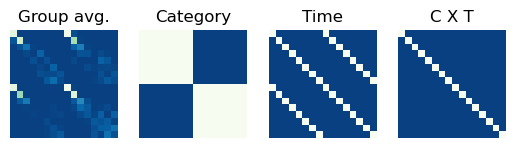

In [ ]:

model_rdms = [group_cm.mean(axis=0), category_rdm, position_rdm, conjunction_rdm]
model_titles = ["Group avg.", "Category", "Time", "C x T"]

fig, axes = plt.subplots(1, 4, sharex=True, sharey=True)
for rdm, ax, title in zip(model_rdms, axes, model_titles):
    sns.heatmap(
        rdm,
        vmin=1 / n_conditions,
        vmax=0.3,
        ax=ax,
        cmap="GnBu_r",
        square=True,
        cbar=False,
    )
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    ax.set_title(title)
    sns.despine(ax=ax, left=True, bottom=True)

## OLS fitting

In [ ]:

df_rsa = []
model_names = ["Position", "Category", "Conjunction"]
model_X = [stats.zscore(rdm.flatten()) for rdm in [position_rdm, category_rdm, conjunction_rdm]]
X_model = sm.add_constant(np.transpose(model_X))

for sub, sub_cm in enumerate(group_cm):
    ranked_vec = stats.rankdata(sub_cm.flatten(), method="average")
    neural_y = stats.zscore(ranked_vec)

    ols = sm.OLS(neural_y, X_model).fit()
    res = dict(zip(model_names, ols.params[1:]))
    res["Subject"] = sub
    df_rsa.append(res)

    del ols, neural_y

df_rsa = pd.DataFrame(df_rsa)

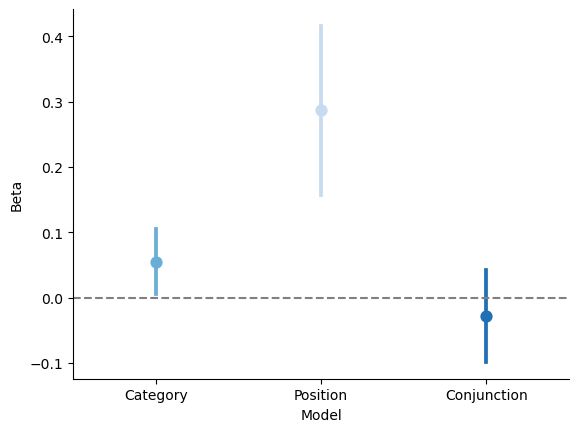

In [5]:
df_melt = df_rsa.melt(id_vars=['Subject'], value_vars=['Position', 'Category', 'Conjunction'], var_name='Model', value_name='Beta')
sns.pointplot(data=df_melt, x='Model', y='Beta',
              order=['Category', 'Position', 'Conjunction'],
              hue='Model', palette='Blues',
            #   errorbar=('pi',95), 
            units='Subject',
            errorbar='sd'
              )
plt.axhline(0, color='gray', linestyle='--')
sns.despine()

In [6]:
pvals = []
for model in ['Position', 'Category', 'Conjunction']:
    col = df_rsa[model]
    t, p = stats.ttest_1samp(col, 0)
    pvals.append(p)
pg.multicomp(pvals, alpha=0.05, method='bonf')

(array([ True,  True, False]),
 array([2.81582775e-07, 8.42771435e-04, 3.43176927e-01]))

## MDS

In [ ]:
def cm_to_rdm(cm):
    """Convert a confusion/similarity matrix to a symmetric dissimilarity matrix."""
    return 1 - 0.5 * (cm + cm.T)

In [ ]:
neural_rdm = cm_to_rdm(np.mean(group_cm, axis=0))
neural_rdm_distance = (neural_rdm - neural_rdm.min()) / (neural_rdm.max() - neural_rdm.min())

mds = MDS(n_components=2, dissimilarity='precomputed', metric=False, random_state=42, n_init=1)
ref_coords = mds.fit_transform(neural_rdm_distance)

In [9]:
coords = list()
for sub_cm in group_cm:
    sub_rdm = cm_to_rdm(sub_cm)
    sub_rdm_distance = (sub_rdm - sub_rdm.min()) / (sub_rdm.max() - sub_rdm.min())
    sub_coords = mds.fit_transform(sub_rdm_distance)
    coords.append(sub_coords)

In [10]:
aligned_coords = []

for sub_coords in coords:
    mtx1, mtx2, disparity = procrustes(ref_coords, sub_coords)
    aligned_coords.append(mtx2)

aligned_coords = np.array(aligned_coords)  # shape: n_subjects x n_conditions x 2

In [11]:
mean_coords = aligned_coords.mean(axis=0)
sem_coords = aligned_coords.std(axis=0, ddof=1) / np.sqrt(group_cm.shape[0])

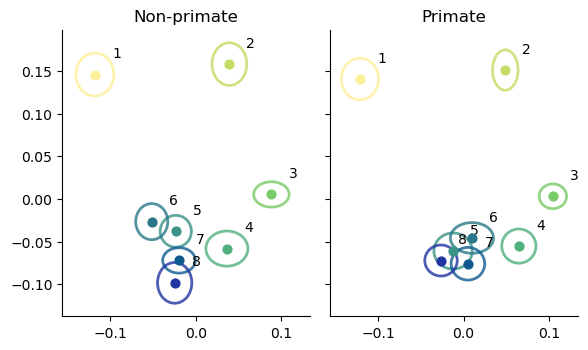

In [12]:
colors = cmaps.haline(np.linspace(0, 1, 9))[::-1]

fig, axes = plt.subplots(1,2, figsize=(6,6), sharex=True, sharey=True)
for (cond_idx, cond_name), ax in zip(enumerate(["Non-primate", 'Primate']), axes):
    for t in range(8):
        i = cond_idx * 8 + t
        x, y = mean_coords[i]
        ex, ey = sem_coords[i]
        c = colors[t]
        
        ellipse = Ellipse(
            (x, y),
            width=2 * ex,
            height=2 * ey,
            edgecolor=c,
            facecolor="none",
            linewidth=2,
            alpha=0.8,
        )
        ax.add_patch(ellipse)
        ax.scatter(x, y, color=c, s=40, zorder=3)
        ax.text(x + 0.02, y + 0.02, f"{t+1}", fontsize=10)

    ax.set_aspect("equal")
    ax.set_title(cond_name)
    sns.despine()
plt.tight_layout()